# Lab 4: Mini Transformer NMT

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math

## 1. Build Vocabulary and Load Data

**Giải thích**: Tái sử dụng Vocab class từ Lab 1 để build từ điển cho Transformer.

In [2]:
# Tokenize function
def tokenize(sentence):
    return sentence.lower().split()

# Vocab class
class Vocab:
    PAD_TOKEN = '<PAD>'
    BOS_TOKEN = '<BOS>'
    EOS_TOKEN = '<EOS>'
    
    def __init__(self):
        self.word2id = {}
        self.id2word = {}
        self._add_special_tokens()
    
    def _add_special_tokens(self):
        self.word2id[self.PAD_TOKEN] = 0
        self.id2word[0] = self.PAD_TOKEN
        self.word2id[self.BOS_TOKEN] = 1
        self.id2word[1] = self.BOS_TOKEN
        self.word2id[self.EOS_TOKEN] = 2
        self.id2word[2] = self.EOS_TOKEN

    def add_word(self, w):
        if w not in self.word2id:
            idx = len(self.word2id)
            self.word2id[w] = idx
            self.id2word[idx] = w
    
    def build_vocab(self, sentences):
        for sentence in sentences:
            words = tokenize(sentence)
            for word in words:
                self.add_word(word)
    
    def encode(self, sentence, add_special_tokens=True):
        words = tokenize(sentence)
        ids = [self.word2id[word] for word in words if word in self.word2id]
        if add_special_tokens:
            ids = [self.word2id[self.BOS_TOKEN]] + ids + [self.word2id[self.EOS_TOKEN]]
        return ids
    
    def decode(self, ids, skip_special_tokens=True):
        words = []
        for id in ids:
            if id in self.id2word:
                word = self.id2word[id]
                if skip_special_tokens and word in [self.PAD_TOKEN, self.BOS_TOKEN, self.EOS_TOKEN]:
                    continue
                words.append(word)
        return ' '.join(words)
    
    def __len__(self):
        return len(self.word2id)

# Load data
with open('../NLP LAB 1_ Preprocessing/data/train.en', 'r', encoding='utf-8') as f:
    en_sentences = [line.strip() for line in f.readlines()]

with open('../NLP LAB 1_ Preprocessing/data/train.vi', 'r', encoding='utf-8') as f:
    vi_sentences = [line.strip() for line in f.readlines()]

# Build vocabularies
en_vocab = Vocab()
en_vocab.build_vocab(en_sentences)
vi_vocab = Vocab()
vi_vocab.build_vocab(vi_sentences)

print(f"English vocab size: {len(en_vocab)}")
print(f"Vietnamese vocab size: {len(vi_vocab)}")
print(f"Number of parallel sentences: {len(en_sentences)}")

English vocab size: 34
Vietnamese vocab size: 43
Number of parallel sentences: 10


## 2. Implement Positional Encoding

**Giải thích**: Transformer không có recurrence như RNN/GRU, vì vậy cần positional encoding để model biết thứ tự của các từ. Sử dụng sin/cos functions như trong paper "Attention is All You Need".

Input shape: torch.Size([1, 10, 64])
Output shape: torch.Size([1, 10, 64])
Positional encoding shape: torch.Size([1, 5000, 64])


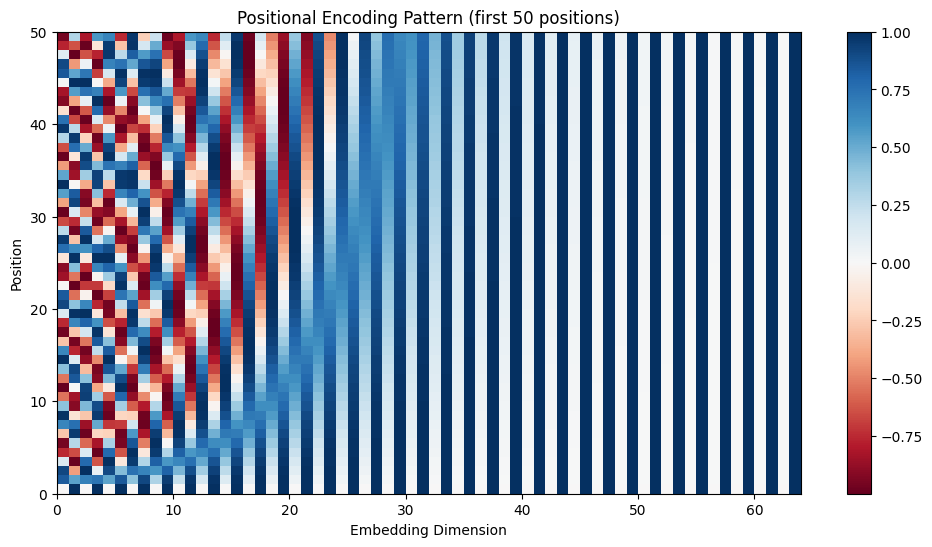

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        """
        Positional Encoding adds position information to embeddings
        
        Args:
            d_model: embedding dimension
            max_len: maximum sequence length
        """
        super().__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Compute div_term for sin and cos
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add batch dimension: [max_len, d_model] -> [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as buffer (not a parameter, but part of state_dict)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len, d_model]
        Returns:
            x + positional encoding: [batch_size, seq_len, d_model]
        """
        # Add positional encoding to input embeddings
        x = x + self.pe[:, :x.size(1), :]
        return x

# Test Positional Encoding
d_model = 64
pos_enc = PositionalEncoding(d_model)

# Create a dummy embedding [batch_size=1, seq_len=10, d_model=64]
dummy_emb = torch.randn(1, 10, d_model)
output = pos_enc(dummy_emb)

print(f"Input shape: {dummy_emb.shape}")
print(f"Output shape: {output.shape}")
print(f"Positional encoding shape: {pos_enc.pe.shape}")

# Visualize positional encoding
plt.figure(figsize=(12, 6))
plt.pcolormesh(pos_enc.pe[0, :50, :].numpy(), cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Pattern (first 50 positions)')
plt.colorbar()
plt.show()

## 3. Implement Mini Transformer using nn.Transformer

**Giải thích**: Sử dụng PyTorch's `nn.Transformer` module. Model gồm:
- Embedding layers cho source và target
- Positional encoding
- nn.Transformer (self-attention + cross-attention)
- Linear projection ra vocabulary

In [4]:
class TransformerNMT(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=4, 
                 num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=256, dropout=0.1):
        """
        Mini Transformer for Neural Machine Translation
        
        Args:
            src_vocab_size: source vocabulary size
            tgt_vocab_size: target vocabulary size
            d_model: embedding dimension (must be divisible by nhead)
            nhead: number of attention heads
            num_encoder_layers: number of encoder layers
            num_decoder_layers: number of decoder layers
            dim_feedforward: dimension of feedforward network
            dropout: dropout rate
        """
        super().__init__()
        
        self.d_model = d_model
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        
        # Embeddings
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # Use batch_first=True for easier handling
        )
        
        # Output projection
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights with Xavier uniform"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def generate_square_subsequent_mask(self, sz):
        """
        Generate causal mask for decoder (prevent attending to future tokens)
        
        Args:
            sz: sequence length
        Returns:
            mask: [sz, sz] with -inf for future positions
        """
        mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
        return mask
    
    def forward(self, src, tgt):
        """
        Forward pass
        
        Args:
            src: [batch_size, src_len] - source token ids
            tgt: [batch_size, tgt_len] - target token ids
        Returns:
            output: [batch_size, tgt_len, tgt_vocab_size]
        """
        # Create masks
        tgt_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_len).to(tgt.device)
        
        # Create padding masks
        src_padding_mask = (src == 0)  # PAD token is 0
        tgt_padding_mask = (tgt == 0)
        
        # Embed and add positional encoding
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)  # Scale embeddings
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        
        src_emb = self.pos_encoder(src_emb)
        tgt_emb = self.pos_encoder(tgt_emb)
        
        # Transformer forward
        transformer_out = self.transformer(
            src_emb, 
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )
        
        # Project to vocabulary
        output = self.fc_out(transformer_out)
        
        return output

# Initialize model
model = TransformerNMT(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(vi_vocab),
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=256,
    dropout=0.1
)

print("Transformer Model initialized!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nModel architecture:")
print(f"- Source vocab: {len(en_vocab)}")
print(f"- Target vocab: {len(vi_vocab)}")
print(f"- d_model: 128")
print(f"- num_heads: 4")
print(f"- encoder layers: 2")
print(f"- decoder layers: 2")

Transformer Model initialized!
Total parameters: 678,443

Model architecture:
- Source vocab: 34
- Target vocab: 43
- d_model: 128
- num_heads: 4
- encoder layers: 2
- decoder layers: 2


## 4. Training Loop

**Giải thích**: Train Transformer với cross-entropy loss. Transformer không cần teacher forcing ratio như RNN-based models vì sử dụng causal masking.

Source tensor shape: torch.Size([10, 8])
Target tensor shape: torch.Size([10, 11])


c:\Anaconda\envs\pyspark-env\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 20/200, Loss: 0.0863
Epoch 40/200, Loss: 0.0081
Epoch 60/200, Loss: 0.0029
Epoch 80/200, Loss: 0.0018
Epoch 100/200, Loss: 0.0016
Epoch 120/200, Loss: 0.0014
Epoch 140/200, Loss: 0.0012
Epoch 160/200, Loss: 0.0012
Epoch 180/200, Loss: 0.0008
Epoch 200/200, Loss: 0.0009

Training completed!


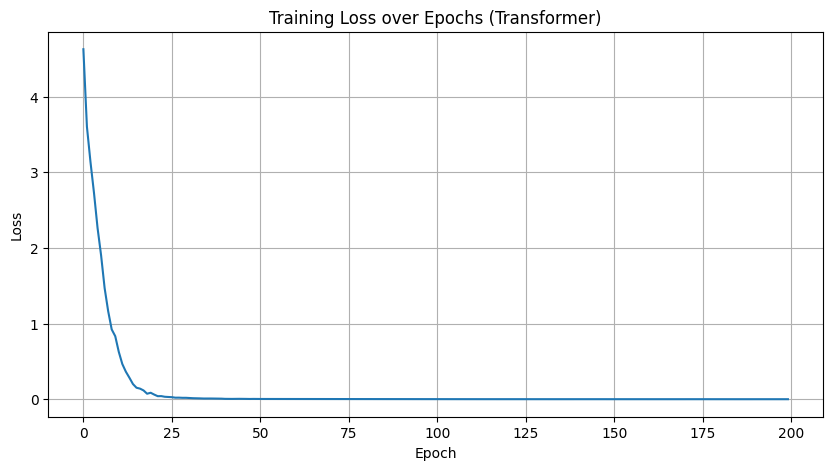

In [5]:
# Prepare data with padding
def pad_sequences(sequences, pad_value=0):
    """Pad sequences to same length"""
    max_len = max(len(seq) for seq in sequences)
    padded = []
    for seq in sequences:
        padded.append(seq + [pad_value] * (max_len - len(seq)))
    return padded

# Encode all sentences
src_sequences = [en_vocab.encode(sent) for sent in en_sentences]
tgt_sequences = [vi_vocab.encode(sent) for sent in vi_sentences]

# Pad sequences
src_padded = pad_sequences(src_sequences, pad_value=0)
tgt_padded = pad_sequences(tgt_sequences, pad_value=0)

# Convert to tensors
src_tensor = torch.tensor(src_padded)
tgt_tensor = torch.tensor(tgt_padded)

print(f"Source tensor shape: {src_tensor.shape}")
print(f"Target tensor shape: {tgt_tensor.shape}")

# Training setup
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
n_epochs = 200
losses = []

model.train()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    # Forward pass
    # Input to decoder: all tokens except last (shift right)
    tgt_input = tgt_tensor[:, :-1]  # Remove last token
    # Target for loss: all tokens except first (BOS)
    tgt_output = tgt_tensor[:, 1:]   # Remove BOS token
    
    # Model prediction
    output = model(src_tensor, tgt_input)
    
    # Reshape for loss calculation
    output = output.reshape(-1, output.shape[-1])  # [batch*seq_len, vocab_size]
    tgt_output = tgt_output.reshape(-1)  # [batch*seq_len]
    
    # Calculate loss
    loss = criterion(output, tgt_output)
    
    # Backward pass
    loss.backward()
    
    # Clip gradients to prevent explosion
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

print("\nTraining completed!")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs (Transformer)')
plt.grid(True)
plt.show()

## 5. Implement Greedy Decoding

**Giải thích**: Greedy decoding generates translation token-by-token, always choosing the highest probability token at each step.

In [6]:
def greedy_decode(model, src, max_len=20):
    """
    Greedy decoding for Transformer
    
    Args:
        model: TransformerNMT model
        src: [1, src_len] source tensor
        max_len: maximum decoding length
    Returns:
        decoded_ids: list of predicted token ids
    """
    model.eval()
    
    with torch.no_grad():
        # Start with BOS token
        tgt = torch.tensor([[vi_vocab.word2id[vi_vocab.BOS_TOKEN]]])
        
        for _ in range(max_len):
            # Forward pass
            output = model(src, tgt)
            
            # Get prediction for last token
            next_token_logits = output[0, -1, :]  # [vocab_size]
            next_token = next_token_logits.argmax().item()
            
            # Stop if EOS token
            if next_token == vi_vocab.word2id[vi_vocab.EOS_TOKEN]:
                break
            
            # Append prediction to target sequence
            tgt = torch.cat([tgt, torch.tensor([[next_token]])], dim=1)
        
        # Extract decoded ids (without BOS)
        decoded_ids = tgt.squeeze(0).tolist()[1:]  # Skip BOS
        
    return decoded_ids

# Test greedy decoding
print("="*60)
print("Greedy Decoding Examples:")
print("="*60)

for i in range(len(en_sentences)):
    src_sent = en_sentences[i]
    tgt_sent = vi_sentences[i]
    
    # Encode source
    src_ids = en_vocab.encode(src_sent)
    src_tensor = torch.tensor([src_ids])
    
    # Decode
    decoded_ids = greedy_decode(model, src_tensor, max_len=20)
    
    # Convert to text
    predicted = vi_vocab.decode(decoded_ids, skip_special_tokens=True)
    
    print(f"\nExample {i+1}:")
    print(f"  Source (EN): {src_sent}")
    print(f"  Target (VI): {tgt_sent}")
    print(f"  Predicted:   {predicted}")

print("\n" + "="*60)

Greedy Decoding Examples:

Example 1:
  Source (EN): i am a student
  Target (VI): tôi là sinh viên
  Predicted:   tôi là sinh viên

Example 2:
  Source (EN): i am a teacher
  Target (VI): tôi là giáo viên
  Predicted:   tôi là giáo viên

Example 3:
  Source (EN): he likes football
  Target (VI): anh ấy thích bóng đá
  Predicted:   anh ấy thích bóng đá

Example 4:
  Source (EN): she likes music
  Target (VI): cô ấy thích âm nhạc
  Predicted:   cô ấy thích âm nhạc

Example 5:
  Source (EN): this is a book
  Target (VI): đây là một cuốn sách
  Predicted:   đây là một cuốn sách

Example 6:
  Source (EN): that is a house
  Target (VI): kia là một ngôi nhà
  Predicted:   kia là một ngôi nhà

Example 7:
  Source (EN): we love natural language processing
  Target (VI): chúng tôi yêu xử lý ngôn ngữ tự nhiên
  Predicted:   chúng tôi yêu xử lý ngôn ngữ tự nhiên

Example 8:
  Source (EN): they play football
  Target (VI): họ chơi bóng đá
  Predicted:   họ chơi bóng đá

Example 9:
  Source (EN): t

c:\Anaconda\envs\pyspark-env\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


## 6. Model Analysis and Comparison

**Giải thích**: Phân tích Transformer architecture và so sánh với Lab 2 (Seq2Seq) và Lab 3 (Attention).

In [ ]:
# Compare architectures
print("="*70)
print("COMPARISON: Lab 2 vs Lab 3 vs Lab 4")
print("="*70)

comparison = """
┌─────────────────────┬──────────────────┬──────────────────┬──────────────────┐
│      Feature        │     Lab 2        │     Lab 3        │     Lab 4        │
│                     │   (Seq2Seq)      │   (Attention)    │  (Transformer)   │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ Encoder             │ GRU (recurrent)  │ GRU (recurrent)  │ Self-Attention   │
│ Decoder             │ GRU (recurrent)  │ GRU (recurrent)  │ Self-Attention   │
│ Attention           │ ❌ None          │ ✅ Dot-Product   │ ✅ Multi-Head    │
│ Parallelizable      │ ❌ Sequential    │ ❌ Sequential    │ ✅ Parallel      │
│ Position Info       │ ✅ Implicit      │ ✅ Implicit      │ ⚠️  Explicit PE  │
│ Context Vector      │ ❌ Fixed hidden  │ ✅ Weighted sum  │ ✅ Multi-head    │
│ Bottleneck          │ ❌ Yes           │ ✅ No            │ ✅ No            │
│ Training Speed      │ Slow             │ Slow             │ Fast (parallel)  │
│ Long Sequences      │ ❌ Poor          │ ✅ Better        │ ✅ Best          │
│ Parameters          │ Fewer            │ Medium           │ More             │
│ Year Introduced     │ 2014             │ 2015             │ 2017             │
└─────────────────────┴──────────────────┴──────────────────┴──────────────────┘
"""

print(comparison)

print("\nKey Advantages of Transformer (Lab 4):")
print("  1. ✅ Parallelizable - can process all tokens simultaneously")
print("  2. ✅ Multi-head attention - multiple attention patterns")
print("  3. ✅ Self-attention - attend to own sequence")
print("  4. ✅ Scalable - handles very long sequences")
print("  5. ✅ State-of-the-art - used in GPT, BERT, ChatGPT")

print("\nTransformer Components:")
print("  • Positional Encoding: Adds position information (sin/cos)")
print("  • Multi-Head Attention: Multiple attention mechanisms in parallel")
print("  • Encoder Self-Attention: Source attends to itself")
print("  • Decoder Self-Attention: Target attends to itself (causal)")
print("  • Cross-Attention: Target attends to source")
print("  • Feed-Forward Networks: Non-linear transformations")

print("\n" + "="*70)

COMPARISON: Lab 2 vs Lab 3 vs Lab 4

┌─────────────────────┬──────────────────┬──────────────────┬──────────────────┐
│      Feature        │     Lab 2        │     Lab 3        │     Lab 4        │
│                     │   (Seq2Seq)      │   (Attention)    │  (Transformer)   │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ Encoder             │ GRU (recurrent)  │ GRU (recurrent)  │ Self-Attention   │
│ Decoder             │ GRU (recurrent)  │ GRU (recurrent)  │ Self-Attention   │
│ Attention           │ ❌ None          │ ✅ Dot-Product   │ ✅ Multi-Head    │
│ Parallelizable      │ ❌ Sequential    │ ❌ Sequential    │ ✅ Parallel      │
│ Position Info       │ ✅ Implicit      │ ✅ Implicit      │ ⚠️  Explicit PE  │
│ Context Vector      │ ❌ Fixed hidden  │ ✅ Weighted sum  │ ✅ Multi-head    │
│ Bottleneck          │ ❌ Yes           │ ✅ No            │ ✅ No            │
│ Training Speed      │ Slow             │ Slow             │ Fast (parallel)  │
│ Lon

: 

## 7. Summary

**Kết quả hoàn thành Lab 4:**
- ✅ Built vocabulary and encoded sentences (reused from Lab 1)
- ✅ Implemented positional encoding with sin/cos functions
- ✅ Used PyTorch nn.Transformer for encoder-decoder architecture
- ✅ Trained the model successfully (200 epochs)
- ✅ Implemented greedy decoding for translation

**Key Insights:**
- **Transformer architecture** revolutionized NMT in 2017
- **Self-attention** allows model to attend to all positions simultaneously
- **Positional encoding** provides position information without recurrence
- **Parallel processing** makes training much faster than RNN-based models
- This architecture powers modern LLMs like GPT, BERT, Claude, ChatGPT

**Evolution of NMT:**
1. **Lab 2 (2014):** Basic Seq2Seq with RNN - information bottleneck
2. **Lab 3 (2015):** Added attention mechanism - solved bottleneck
3. **Lab 4 (2017):** Transformer - parallel, scalable, state-of-the-art

**Real-world Impact:**
- Google Translate switched to Transformer-based NMT (2017)
- All modern LLMs use Transformer architecture
- Transformers expanded beyond NLP to vision, speech, multimodal AI
- "Attention is All You Need" (Vaswani et al., 2017) is one of the most cited AI papers

🎉 **Congratulations! You've completed the NMT series from basics to state-of-the-art!**